In [15]:
import gc
gc.collect()

24

In [16]:
#Progressive Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def plotp(images, titles=None, fig_title='', vmax=None):

    images = np.asarray(images)

    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(8, 8))

    if vmax is None:
        v = np.max(np.abs(images[0]))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else "")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(i):
        data = np.abs(images[i])

        v = vmax if vmax is not None else np.max(data)
        im.set_data(data / v)

        if titles:
            ax.set_title(f"image {i}: {titles[i]}")

        fig.canvas.draw_idle()

    interact(view_image, i=IntSlider(value=0, min=0, max=len(images)-1, step=1)
)


In [17]:
# # Plot animation

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation


# def plotani(imgs, titles=None, interval=400, cmap='gray',
#               vmin=None, vmax=None):
#     """
#     Create an animated figure from a list or array of images.

#     Parameters
#     ----------
#     imgs : list or np.ndarray
#         List or array of 2D images, shape (N, Nx, Ny)
#     titles : list of str, optional
#         Title for each frame
#     interval : int
#         Time between frames in ms
#     cmap : str
#         Colormap
#     vmin, vmax : float, optional
#         Intensity limits (recommended to avoid flicker)
#     """

#     imgs = np.asarray(imgs)

#     # magnitude if complex
#     if np.iscomplexobj(imgs):
#         imgs = np.abs(imgs)

#     if vmin is None:
#         vmin = np.percentile(imgs, 2)
#     if vmax is None:
#         vmax = np.percentile(imgs, 98)

#     fig, ax = plt.subplots()
#     im = ax.imshow(imgs[0], cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.axis('off')

#     def update(frame):
#         im.set_data(imgs[frame])
#         if titles is not None:
#             ax.set_title(titles[frame])
#         return [im]

#     ani = animation.FuncAnimation(
#         fig,
#         update,
#         frames=len(imgs),
#         interval=interval,
#         blit=True
#     )

#     plt.show()
#     return ani


In [14]:
#single image plot
import matplotlib.pyplot as plt

def plot (data,rotate=True):
    if rotate:
        # data=np.flip(data,axis=-3)
        data=np.rot90(data,k=-1,axes=(-2,-1))
        data=np.flip(data,axis=-2)
        pass

    plt.figure()
    plt.imshow(abs(data),cmap='gray')

In [18]:
#plot Progessive grid 
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotpg(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True):
    """
    Plots a list of images in a dynamic subplot grid.
    
    Parameters:
    - images: List of 2D numpy arrays.
    - titles: List of strings for each subplot.
    - cmap: Colormap (default 'gray').
    - vmin/vmax: Windowing levels. If None, scales to each image's min/max.
    """
    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
  
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        vs.append(v)
        images[i]/=v
        ax = axes_flat[i]
        im = ax.imshow(abs(images[i][0]), cmap=cmap)
        ims.append(im)
      
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            ims[i].set_data(abs(images[i][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            if titles:
                ims[i].axes.set_title(titles[p], fontsize=10, pad=4)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [19]:
#plot grid Partitions
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotg(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True):

    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        # v =v.astype(np.float32)
        vs.append(v)
        # images[i] = images[i].astype(np.float32)
        images[i]/=v
        ax = axes_flat[i]
        im = ax.imshow(abs(images[i][0]), cmap=cmap)
        ims.append(im)
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            ims[i].set_data(abs(images[i][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [20]:
#plot grid Reps / Partitions
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotgRP(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True,phase=False):

    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        # v =v.astype(np.float32)
        vs.append(v)
        # images[i] = images[i].astype(np.float32)
        images[i]=images[i]/v
        ax = axes_flat[i]
        if phase is False:
            im = ax.imshow(abs(images[i][0][0]), cmap=cmap)
        else:
            im = ax.imshow(np.angle(images[i][0][0]), cmap=cmap)
        ims.append(im)
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(r,p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            if phase is False:
                ims[i].set_data(abs(images[i][r][p]))
            else:
                ims[i].set_data(np.angle(images[i][r][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0][0])-1, step=1),
                         r=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [21]:
#Windowed Progressive Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def plotw(images, titles=None, rotate=False, fig_title=None, vmax=None):
    
    if hasattr(images, 'get'): 
        images = images.get()
    images = np.asarray(images)

    if rotate:
        images=np.flip(images,axis=-3)
        images=np.rot90(images,k=-1,axes=(1,2))
        images=np.flip(images,axis=-2)


    

    
    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(8, 8))
    if vmax is None:
        v = np.max(np.abs(images[0]))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else "")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(i,v_min,v_max):
        data = np.abs(images[i])

        v = vmax if vmax is not None else np.max(data)
        im.set_data(data / v)
        im.set_clim(vmin=v_min,vmax=v_max)
        if titles:
            # ax.set_title(f"image {i}: {titles[i]}") 
            ax.set_title(titles[i]) 

        fig.canvas.draw_idle()

    interact(view_image, i=IntSlider(value=0, min=0, max=len(images)-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


In [22]:
#Windowed Partitions/Reps Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def plotRP(images, titles=None, rotate=False, fig_title=None, vmax=None):
    
    if hasattr(images, 'get'): 
        images = images.get()
    images = np.asarray(images)

    if rotate:
        images=np.flip(images,axis=-3)
        images=np.rot90(images,k=-1,axes=(1,2))
        images=np.flip(images,axis=-2)


    

    
    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(6, 6))
    if vmax is None:
        v = np.max(np.abs(images))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0][0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else " Reps index:0 , Part index:0 ")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(r, p, v_min,v_max):
        data = np.abs(images[r][p])

        im.set_data(data / v)
        im.set_clim(vmin=v_min,vmax=v_max)
        ax.set_title(titles[p] if titles else f" , Reps index:{r}, Part index:{p}") 

        fig.canvas.draw_idle()

    interact(view_image, r = IntSlider(value=0, min=0, max=len(images)-1, step=1),
                         p = IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min = FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max = FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


In [23]:
#rotate Dicom to match .dat images 
def rot (volume,part=False,k=-1,flip=True,CEST=False):
    volume=np.array(volume)
    if CEST:
        volume=np.flip(volume,axis=-4)
    if part:
        volume=np.flip(volume,axis=-3)
    volume=np.rot90(volume,k=k,axes=(-2,-1))
    if flip:
        volume=np.flip(volume,axis=-2)
    return volume
    

imgs shape (34, 24, 96, 114)


interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=23)…

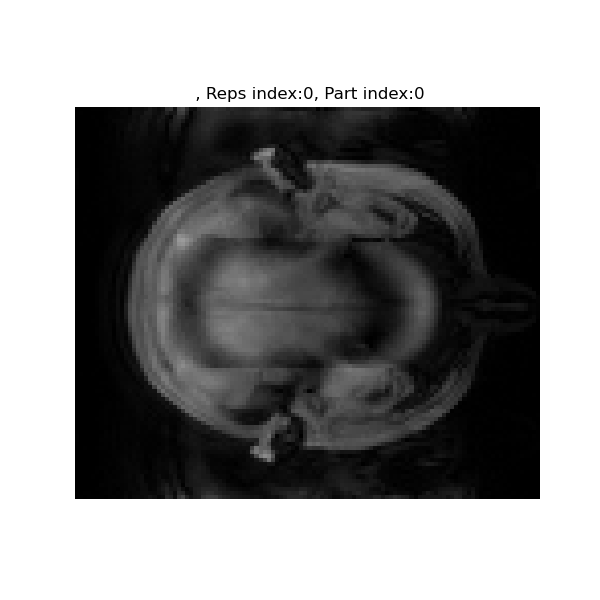

In [19]:
#view imgs from h5 files
import numpy as np
import h5py
import sigpy as sp
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

# Rep=0 #selected partition 
data=[]
titles=[]

#SENSE recon (poor mps)
imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp_imgs.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)

    imgs=f['imgs'][:]
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
# abs(imgs) 
# titles.append('SENSE recon (Goo mps)')

plotRP(imgs)


<KeysViewHDF5 ['mps']>
mps shape (44, 24, 96, 114)
<KeysViewHDF5 ['mps']>

mps shape (44, 24, 96, 114)
<KeysViewHDF5 ['refs']>
ACS shape: (44, 24, 96, 114)
<KeysViewHDF5 ['refs']>

<KeysViewHDF5 ['mps']>, 114)
<KeysViewHDF5 ['refs']>


mps shape (44, 24, 94, 114))
<KeysViewHDF5 ['refs']>



<KeysViewHDF5 ['mps']>

<KeysViewHDF5 ['mps']>
mps shape (44, 24, 96, 114)


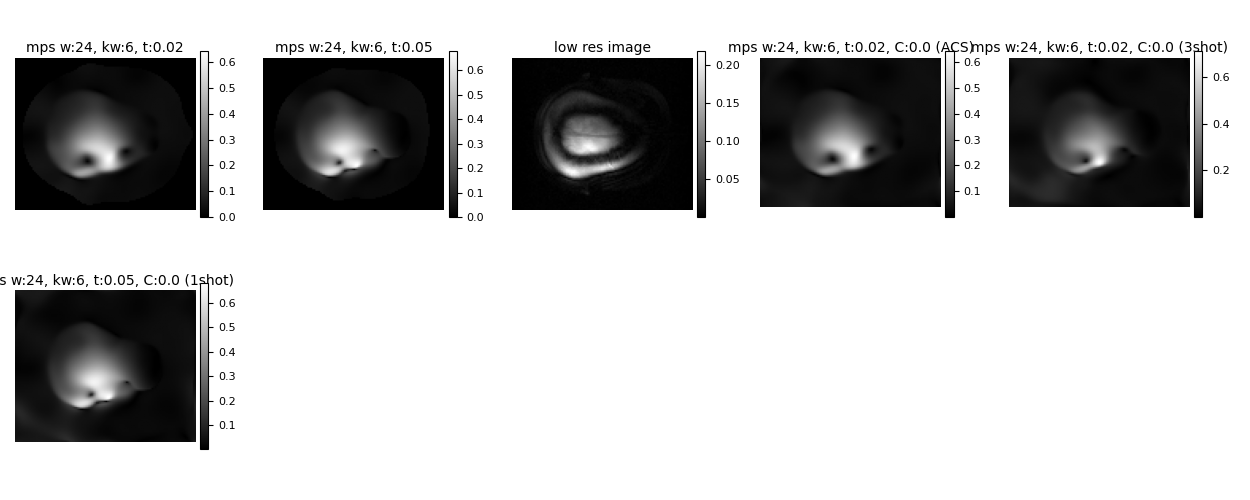

interactive(children=(IntSlider(value=0, description='r', max=43), IntSlider(value=0, description='p', max=23)…

179

In [20]:
#view  maps (separate ACS data)

# ##import bart 
# import sys
# import os
# bart_python_path = '/home/woody/iwbi/iwbi112h/USER-SPACK/opt/linux-ubuntu24.04-x86_64_v3/gcc-13.3.0/bart-0.7.00-lkbpv5zad56b5vo2lro2xpt5ikp7g4oh/lib/python3.11/site-packages'
# sys.path.insert(0, bart_python_path)
# import bart
# import cfl
##################################
import torch 
import numpy as np
import h5py
import sigpy as sp

bart_dir='/home/vault/iwbi/iwbi112h/CEST_DATA/bart/'
DATA_DIR='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/'
file='mps_c_0.8_t0.02_w_24_kw_6_sp_ksp_2D_R34_C44_1shot.h5'
data=[]
titles=[]
part=slice(None)
# part=20

imgs=[]
with h5py.File(DATA_DIR+file,'r') as f:
    print (f.keys())
    imgs=f['mps'][:]
data.append(imgs[:,part,...])
titles.append('mps w:24, kw:6, t:0.02')
print('mps shape',imgs.shape)

# imgs=[]
# file='mps_c_0.8_t0.01_w_24_kw_6_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:6, t:0.01')
# print('mps shape',imgs.shape)

# imgs=[]
# file='mps_c_0.8_t0.0_w_24_kw_6_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:6, t:0.0')


imgs=[]
file='mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_2D_R34_C44_1shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print (f.keys())
    imgs=f['mps'][:]
data.append(imgs[:,part,...])
titles.append('mps w:24, kw:6, t:0.05')
print('mps shape',imgs.shape)

print('mps shape',imgs.shape)

# imgs=[]
# file='mps_c_0.8_t0.035_w_24_kw_6_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:6, t:0.035')
# print('mps shape',imgs.shape)


# imgs=[]
# file='mps_c_0.8_t0.02_w_20_kw_6_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:20, kw:6, t:0.02')
# print('mps shape',imgs.shape)


#ACS data image
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'
file='ACS_3D_C44_1shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=f['refs'][:]
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('ACS shape:',imgs.shape)
imgs=sp.ifft(imgs,axes=[-3,-2,-1])
# imgs=sp.rss(imgs,axes=-4)
data.append(abs(imgs[:,part,...]))
titles.append('low res image')
DATA_DIR='/home/hpc/iwbi/iwbi112h/LLR codebooks/lab_llr_alhaidari/maps/'

# imgs=[]
# file='mps_c_0.8_t0.02_w_32_kw_6_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:32, kw:6, t:0.02')
# print('mps shape',imgs.shape)


imgs=[]
file='mps_c_0_t0.02_w_24_kw_6_sp_ksp_3D_R34_C44_1shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print (f.keys())
    imgs=f['mps'][:]
data.append(imgs[:,part,...])
titles.append('mps w:24, kw:6, t:0.02, C:0.0 (ACS)')
print('mps shape',imgs.shape)

imgs=[]
file='mps_c_0_t0.02_w_24_kw_6_sp_ksp_3D_R34_C44_3shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print (f.keys())
    imgs=f['mps'][:]
data.append(imgs[:,part,...])
titles.append('mps w:24, kw:6, t:0.02, C:0.0 (3shot)')
print('mps shape',imgs.shape)

imgs=[]
file='mps_c_0_t0.05_w_24_kw_6_sp_ksp_3D_R34_C44_1shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print (f.keys())
    imgs=f['mps'][:]
data.append(imgs[:,part,...])
titles.append('mps w:24, kw:6, t:0.05, C:0.0 (1shot)')
print('mps shape',imgs.shape)

# imgs=[]
# file='mps_class.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps rss normalized img')
# print('mps shape',imgs.shape)



# #########################################3
# #bart mps
# file='/home/vault/iwbi/iwbi112h/CEST_DATA/bart/mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_3D_R34_C44_1shot'
# mps=cfl.readcfl(file)
# mps=mps.T
# print('BART mps shape',mps.shape)
# data.append(mps[:,part,...])
# titles.append('mps w:24, kw:6, t:0.05 (BART)')

# file='/home/vault/iwbi/iwbi112h/CEST_DATA/bart/mps_c_0.8_t0.02_w_24_kw_6_sp_ksp_3D_R34_C44_1shot'
# mps=cfl.readcfl(file)
# mps=mps.T
# print('BART mps shape',mps.shape)
# data.append(mps[:,part,...])
# titles.append('mps w:24, kw:6, t:0.02 (BART)')

# del mps

# ###################################################

# imgs=[]
# file='mps_c_0.8_t0.02_w_24_kw_8_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:8, t:0.02')
# print('mps shape',imgs.shape)

# imgs=[]
# file='mps_c_0.8_t0.02_w_24_kw_10_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:10, t:0.02')
# print('mps shape',imgs.shape)

# imgs=[]
# file='mps_c_0.8_t0.05_w_24_kw_8_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:8, t:0.05')
# print('mps shape',imgs.shape)


# imgs=[]
# file='mps_c_0.8_t0.05_w_24_kw_10_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:24, kw:10, t:0.05')
# print('mps shape',imgs.shape)


# imgs=[]
# file='mps_c_0.8_t0.02_w_20_kw_10_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:20, kw:10, t:0.02')
# print('mps shape',imgs.shape)

# imgs=[]
# file='mps_c_0.8_t0.05_w_20_kw_10_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:20, kw:10, t:0.05')
# print('mps shape',imgs.shape)

# imgs=[]
# file='mps_c_0.8_t0.02_w_18_kw_10_sp_ksp_3D_R34_C44_1shot.h5'
# with h5py.File(DATA_DIR+file,'r') as f:
#     print (f.keys())
#     imgs=f['mps'][:]
# data.append(imgs[:,part,...])
# titles.append('mps w:18, kw:10, t:0.02')
# print('mps shape',imgs.shape)

len(data)
# plotg(data,cols=4,titles=titles)
plotgRP(data,cols=5,titles=titles)

del data
del imgs
gc.collect()

In [ ]:
#exploring ACS data and recon images for NaNs
imgs=[]
# imgs_2=[]
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x1x1_r_0.01_i_1_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.025_w_24_kw_6_sp_ksp.h5'
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x2x2_r_0.01_i_5_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_0.8_1shot.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.array(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

# imgs.shape
# np.isnan(imgs).sum()
import matplotlib.pyplot as plt

# Look at Slice 5, Coil 0
plt.figure()
plt.imshow(np.isnan(imgs[1, 1, :, :]), cmap='gray')
plt.title("White pixels = NaNs")
plt.show()

grappa recon shape: torch.Size([34, 24, 96, 114])
grappa recon shape: (34, 24, 96, 114)


/tmp/ipykernel_4120171/1855003136.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  volume=np.array(volume)


SENSE recon shape after transpose: (34, 24, 96, 114)
LLR recon shape after concatenation: (34, 24, 96, 114)
ACS imgs shape: (24, 96, 114)
ACS shape after repeat: (34, 24, 96, 114)
<KeysViewHDF5 ['kdat_01', 'kdat_02']>
fully sampled 3shot shape: (34, 24, 96, 114)


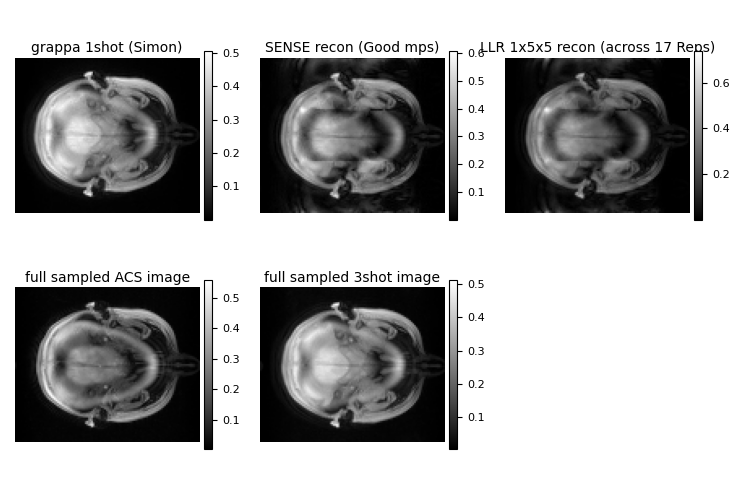

interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=23)…

In [24]:
#view imgs recon by Simon (1shot || Cart us factor = 3)
import torch 
import numpy as np
import h5py
import sigpy as sp
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

# Rep=0 #selected partition 
data=[]
titles=[]

#simon images
file='imgs_grappa_1shot.pth'
# file='imgs_3shot.pth'
imgs=torch.load(DATA_DIR+file)
imgs=np.permute_dims(imgs,(0,3,2,1))
print('grappa recon shape:',imgs.shape)
imgs=rot(imgs,part=True,flip=False,k=-2)
imgs=np.roll(imgs,shift=1,axis=-3)
print('grappa recon shape:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(imgs)
titles.append('grappa 1shot (Simon)')


# with h5py.File(DATA_DIR+'imgs_grappa_1shot_simon.h5','w') as f:
# with h5py.File(DATA_DIR+'imgs_3shot_simon.h5','w') as f:
#     f.create_dataset('imgs',data=imgs)


# #SENSE recon (poor mps)
# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.02_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# # data.append(imgs[Rep,...]) #for a certain Rep
# abs(imgs) 
# titles.append('SENSE recon (poor mps)')

# #SENSE recon (PE:96)
# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_PE1_96.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# # data.append(imgs[Rep,...]) #for a certain Rep
# abs(imgs) 
# titles.append('SENSE recon ( PE1:96)')

#SENSE recon (good mps)
imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
data.append(imgs)
titles.append('SENSE recon (Good mps)')

#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(imgs)
titles.append('LLR 1x5x5 recon (across 17 Reps)')
del imgs, imgs_2

# #LLR recon (over 34 Reps)
# imgs=[]
# file='CEST_LLR_recons_Reps_0_34_RO_0_114_1x5x5_r_1e-06_i_30_2D_kdat_3D_R34_C44_1shot_mps_0.8_1shot.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # keys=list(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.array(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('LLR recon shape after transpose:',imgs.shape)
# # data.append(imgs[Rep,...]) #for a certain Rep
# abs(imgs) 
# titles.append('LLR 1x5x5 recon (across 34 Reps)')


imgs=[]
## fully sampled ACS images
file='ACS_3D_C44_1shot_ifft_imgs.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    # print(f.keys())
    imgs=f['imgs'][:]
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('ACS imgs shape:',imgs.shape)
imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
print('ACS shape after repeat:',imgs.shape)

data.append(imgs)
titles.append('full sampled ACS image')

## fully sampled ACS images
imgs=[]
file='ifft_recon_3shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=np.concat([f[k][:] for k in f.keys()],axis=0)
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('fully sampled 3shot shape:',imgs.shape)
# imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
# print('ACS shape after repeat:',imgs.shape)

data.append((imgs))
titles.append('full sampled 3shot image')

del imgs

# plotg(data,cols=3,titles=titles)
plotgRP(data,cols=3,titles=titles,phase=False)
del data

<KeysViewHDF5 ['kdat_01', 'kdat_02']>
fully sampled 3shot shape: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)

SENSE recon shape after transpose: (34, 24, 96, 114)

SENSE recon shape after transpose: (34, 24, 96, 114)

SENSE recon shape after transpose: (34, 24, 96, 114)

LLR recon shape after concatenation: (34, 24, 96, 114)



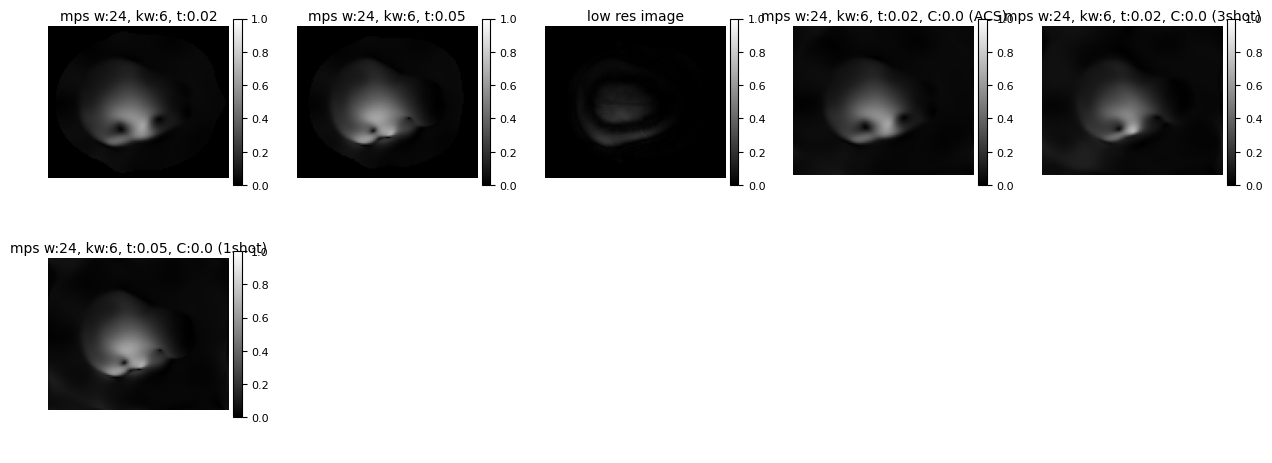

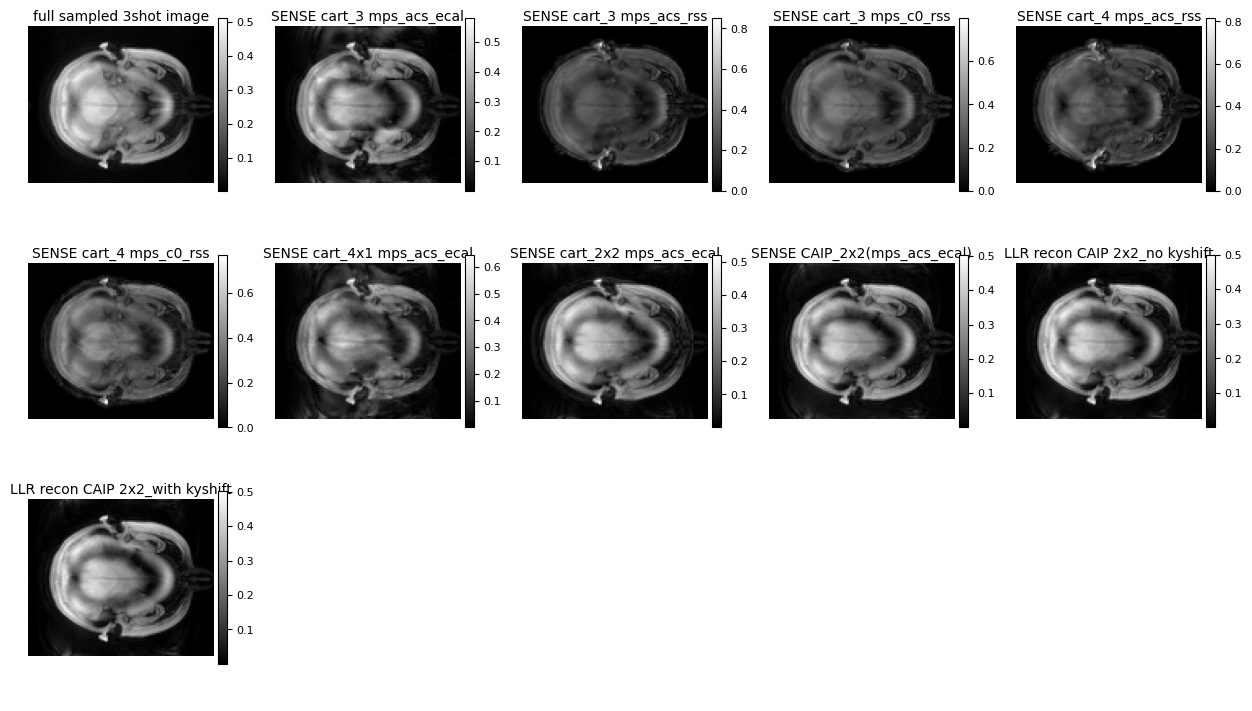

interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=23)…

In [14]:
#view retro US images (3SHOTS)
import h5py
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

data=[]
titles=[]


imgs=[]
## fully sampled ACS images
file='ifft_recon_3shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=np.concat([f[k][:] for k in f.keys()],axis=0)
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('fully sampled 3shot shape:',imgs.shape)
# imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
# print('ACS shape after repeat:',imgs.shape)

data.append(abs(imgs))
titles.append('full sampled 3shot image')

# #simon images
# file='imgs_grappa_1shot.pth'
# # file='imgs_3shot.pth'
# imgs=torch.load(DATA_DIR+file)
# imgs=np.permute_dims(imgs,(0,3,2,1))
# print('grappa recon shape:',imgs.shape)
# imgs=rot(imgs,part=True,flip=False,k=-2)
# imgs=np.roll(imgs,shift=1,axis=-3)
# # data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(imgs)) 
# titles.append('grappa 1shot (Simon)')



imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_3 mps_acs_ecal')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_acs_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_3 mps_acs_rss')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_c0_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_3 mps_c0_rss')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_acs_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_4 mps_acs_rss')


imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_c0_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_4 mps_c0_rss')


imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_3shot_us_Cart_4x1_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'


RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_4x1 mps_acs_ecal')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_3shot_us_Cart_2x2_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE cart_2x2 mps_acs_ecal')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_6_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE recon_3shot_us_cart_6_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_8_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE recon_3shot_us_cart_8_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_10_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE recon_3shot_us_cart_10_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_12_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE recon_3shot_us_cart_12_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_PE1_94.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE us_CAIP_2x2(ACS mps_PE1:94)')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.02_w_24_kw_6_sp_ksp_PE1_94.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE us_CAIP_2x2(CEST mps_PE1:94)')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.02_w_24_kw_6_sp_ksp_CEST_mps.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE CAIP_2x2(mps_c0_ecal)')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_3shot_us_CAIP_2x2_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(imgs))
titles.append('SENSE CAIP_2x2(mps_acs_ecal)')




# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(imgs))
# titles.append('SENSE CAIP_3x2 mps_acs_ecal ')


#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(abs(imgs)) 
titles.append('LLR recon CAIP 2x2_no kyshift')
del imgs, imgs_2

#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_True_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_True_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(abs(imgs)) 
titles.append('LLR recon CAIP 2x2_with kyshift')
del imgs, imgs_2




plotgRP(data,titles=titles,cols=5)
# plotgp(data[None,...],titles=titles,)
# data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(imgs)) 
# titles.append('SENSE recon (poor mps)')
del data

<KeysViewHDF5 ['kdat_01', 'kdat_02']>
fully sampled 3shot shape: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
SENSE recon shape after transpose: (34, 24, 96, 114)
LLR recon shape after concatenation: (34, 24, 96, 114)
LLR recon shape after concatenation: (34, 24, 96, 114)


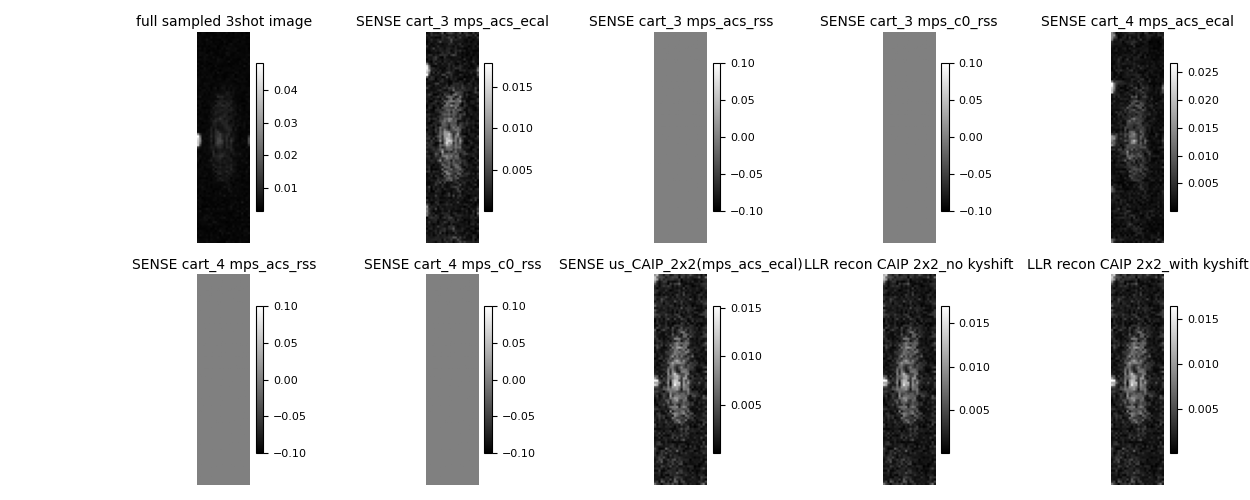

interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=113…

In [ ]:
#view retro US images _sagitals
import h5py
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

sag_dims=(-4,-1,-2,-3)

data=[]
titles=[]


imgs=[]
## fully sampled ACS images
file='ifft_recon_3shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=np.concat([f[k][:] for k in f.keys()],axis=0)
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('fully sampled 3shot shape:',imgs.shape)
# imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
# print('ACS shape after repeat:',imgs.shape)

data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('full sampled 3shot image')

# #simon images
# file='imgs_grappa_1shot.pth'
# # file='imgs_3shot.pth'
# imgs=torch.load(DATA_DIR+file)
# imgs=np.permute_dims(imgs,(0,3,2,1))
# print('grappa recon shape:',imgs.shape)
# imgs=rot(imgs,part=True,flip=False,k=-2)
# imgs=np.roll(imgs,shift=1,axis=-3)
# # data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(np.transpose(imgs,axes=sag_dims))) 
# titles.append('grappa 1shot (Simon)')



imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_3 mps_acs_ecal')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_acs_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_3 mps_acs_rss')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_3_mps_c0_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_3 mps_c0_rss')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_4 mps_acs_ecal')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_acs_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_4 mps_acs_rss')


imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_4_mps_c0_rss.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE cart_4 mps_c0_rss')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_6_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE recon_3shot_us_cart_6_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_8_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE recon_3shot_us_cart_8_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_10_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE recon_3shot_us_cart_10_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_Cart_12_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE recon_3shot_us_cart_12_PE1_94')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0.8_t0.05_w_24_kw_6_sp_ksp_PE1_94.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE us_CAIP_2x2(ACS mps_PE1:94)')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.02_w_24_kw_6_sp_ksp_PE1_94.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE us_CAIP_2x2(CEST mps_PE1:94)')

# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.02_w_24_kw_6_sp_ksp_CEST_mps.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE CAIP_2x2(mps_c0_ecal)')

imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_4_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('SENSE recon shape after transpose:',imgs.shape)
data.append(abs(np.transpose(imgs,axes=sag_dims)))
titles.append('SENSE us_CAIP_2x2(mps_acs_ecal)')




# imgs=[]
# file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_R34_C44_3shot_us_CAIP_6_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
# RO_start=0
# RO_end=114
# with h5py.File(DATA_DIR+file,'r')as f:
#     # print(f.keys())
#     # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
#     for RO_idx in range(RO_start,RO_end): 
#         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
# imgs=np.asarray(imgs)
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
# print('SENSE recon shape after transpose:',imgs.shape)
# data.append(abs(np.transpose(imgs,axes=sag_dims)))
# titles.append('SENSE CAIP_3x2 mps_acs_ecal ')


#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(abs(np.transpose(imgs,axes=sag_dims))) 
titles.append('LLR recon CAIP 2x2_no kyshift')
del imgs, imgs_2

#LLR recon ( 1x5x5 || 2_splits)
imgs=[]
imgs_2=[]
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_True_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_3shot_us_CAIP_4_yshift_True_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))

with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('LLR recon shape after concatenation:',imgs.shape)
# data.append(imgs[...]) #for a certain Rep
imgs=np.nan_to_num(imgs, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data.append(abs(np.transpose(imgs,axes=sag_dims))) 
titles.append('LLR recon CAIP 2x2_with kyshift')
del imgs, imgs_2




plotgRP(data,titles=titles,cols=5)
# plotgp(data[None,...],titles=titles,)
# data.append(imgs[Rep,...]) #for a certain Rep
# data.append(abs(np.transpose(imgs,axes=sag_dims))) 
# titles.append('SENSE recon (poor mps)')
del data

(70, 448, 360)


interactive(children=(IntSlider(value=0, description='i', max=69), FloatSlider(value=0.0, description='Min (Bl…

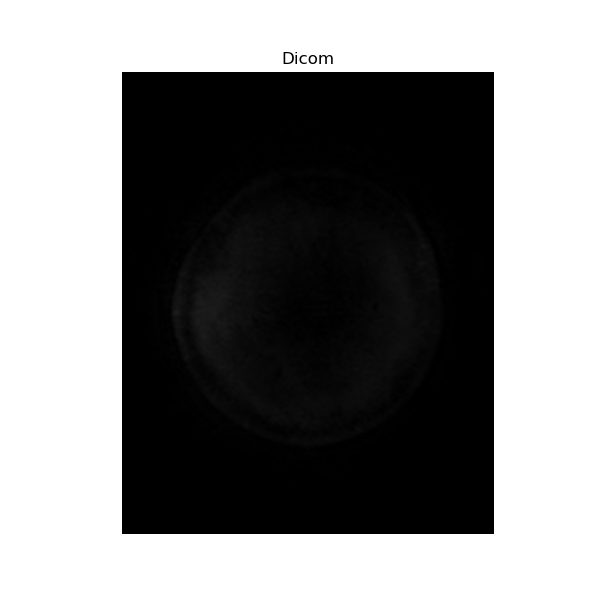

In [ ]:
#Dicom images 
from pydicom import dcmread

file_dcm='/home/hpc/iwbi/iwbi112h/LLR_Daten/HighResMelon/dicom/100_wip_Snap_Cai_4_3_1-1-2_1p00_53_MR/9.dcm'

dcm=dcmread(file_dcm).pixel_array
print(np.shape(dcm))
img_dcm=dcm[36,...]
plotw(dcm,'Dicom',rotate=False,vmax=abs(np.max(img_dcm)))

# import h5py
# with h5py.File('/home/vault/iwbi/iwbi112h/CEST_Data/CEST_WM_dicom.h5','w') as f:
#     f.create_dataset('dcm_Rep_8', data=dcm, chunks=(1, dcm.shape[1], 1))

<KeysViewHDF5 ['kdat_01', 'kdat_02']>
imgs shape before concat: [(17, 24, 96, 114), (17, 24, 96, 114)]
imgs shape: (34, 24, 96, 114)
orignal dyn. range: 2.623388581923791e-06 - 0.001043512369506061 
imgs shape: (34, 24, 96, 114)


interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=23)…

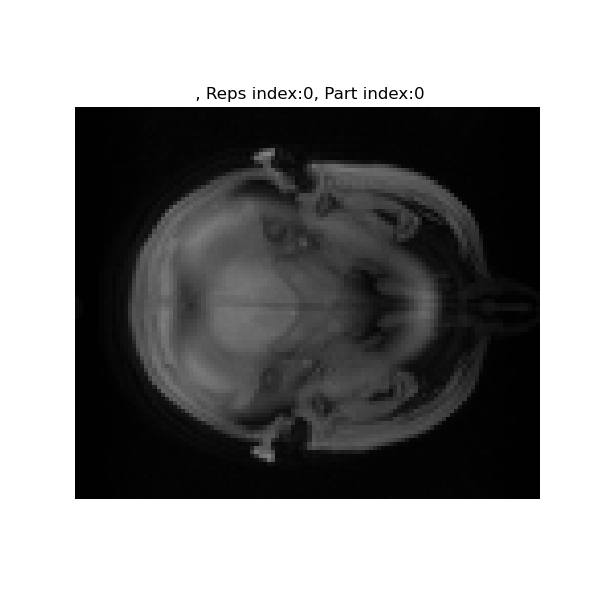

In [ ]:
#3shot ifft recon 
import h5py
import numpy as np

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'
# file='CEST_GRAPPA_recons_65.h5' # clipped grappa for 65 Reps 
file='ifft_recon_3shot.h5'
imgs=[]
data_keys = ['kdat_01','kdat_02']

with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    for data in data_keys:
        imgs.append(f[data][:])

# min_val=np.min(abs(np.array(imgs)))
# max_val=np.max(abs(np.array(imgs)))
print('imgs shape before concat:',[img.shape for img in imgs])
imgs=np.array(imgs)
imgs=np.concatenate(imgs,axis=0)
print('imgs shape:',imgs.shape)
print(f'orignal dyn. range: {np.min(abs(imgs))} - {np.max(abs(imgs))} ')
# imgs=np.permute_dims(imgs,(1,2,0))
print('imgs shape:',imgs.shape)
# plotw(imgs,min_val=min_val,max_val=max_val)
# plotw(imgs,'GRAPPA',dynasdcm=False, norm=True )
plotRP(imgs)
# img_g=imgs[36,...]